<a href="https://colab.research.google.com/github/Madhankumar7-V/SpaceWeatherPrediction/blob/main/Space_Weather_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow ipywidgets seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 33.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error

import ipywidgets as widgets
from IPython.display import display

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving omni_min.lst to omni_min.lst


In [ ]:
columns=[
'Year','Day','Hour',
'Bx','By','Bz',
'FlowSpeed',
'ProtonDensity',
'ProtonTemperature'
]

In [ ]:
data=pd.read_csv(
'omni_min.lst',
sep='\s+',
names=columns
)

data.head()

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_27202/1227749160.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


,Year,Day,Hour,Bx,By,Bz,FlowSpeed,ProtonDensity,ProtonTemperature
2025,1,0,0,-8.13,11.69,-0.38,99999.9,999.99,9999999.0
2025,1,0,1,-8.31,11.81,0.44,99999.9,999.99,9999999.0
2025,1,0,2,-8.31,11.81,0.44,99999.9,999.99,9999999.0
2025,1,0,3,-7.37,12.18,0.40,99999.9,999.99,9999999.0
2025,1,0,4,-8.65,11.42,-1.61,421.5,18.34,203312.0


In [ ]:
data.replace(
[9999.99,99999.9,999.99,9999999],
np.nan,
inplace=True
)

data.dropna(inplace=True)

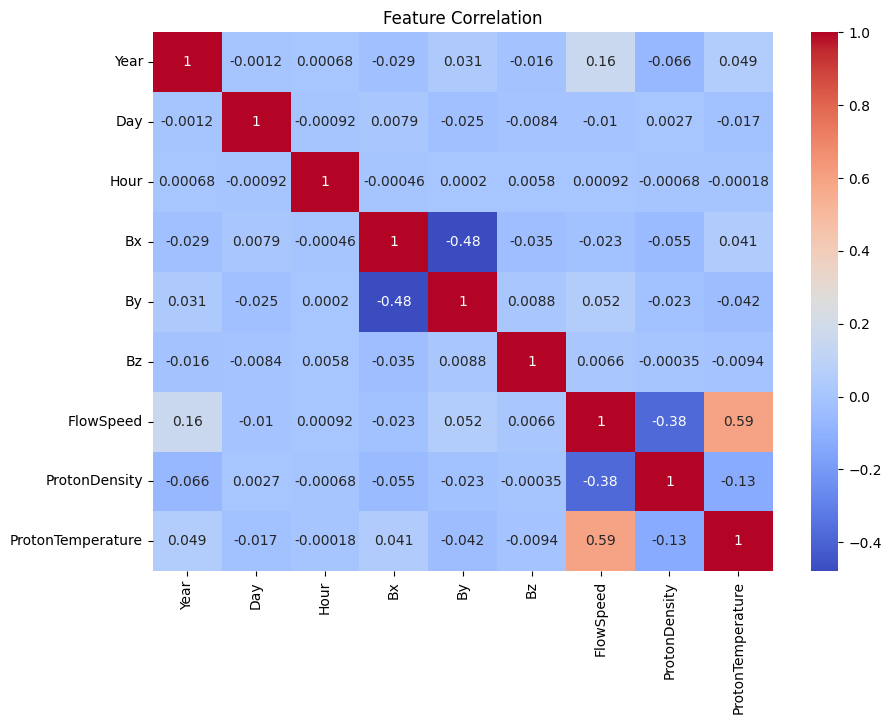

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(
data.corr(),
annot=True,
cmap='coolwarm'
)

plt.title(
"Feature Correlation"
)

plt.show()

In [ ]:
features=[
'Bx',
'By',
'FlowSpeed',
'ProtonDensity',
'ProtonTemperature'
]

X=data[features]
y=data['Bz']

In [ ]:
X_scaler=MinMaxScaler(
feature_range=(-1,1)
)

y_scaler=MinMaxScaler(
feature_range=(-1,1)
)

X_scaled=X_scaler.fit_transform(X)

y_scaled=y_scaler.fit_transform(
y.values.reshape(-1,1)
)

In [ ]:
def create_sequences(
X,
y,
steps=20
):

 X_seq=[]
 y_seq=[]

 for i in range(
 len(X)-steps
 ):

   X_seq.append(
   X[i:i+steps]
   )

   y_seq.append(
   y[i+steps]
   )

 return np.array(X_seq),np.array(y_seq)


X_seq,y_seq=create_sequences(
X_scaled,
y_scaled
)

In [ ]:
X_train,X_test,y_train,y_test= train_test_split(
X_seq,
y_seq,
test_size=0.2,
random_state=42
)

In [ ]:
model=tf.keras.Sequential([

tf.keras.layers.LSTM(
128,
return_sequences=True,
input_shape=(20,5)
),

tf.keras.layers.Dropout(0.2),

tf.keras.layers.LSTM(
64,
return_sequences=True
),

tf.keras.layers.LSTM(
32
),

tf.keras.layers.Dense(
32,
activation='tanh'
),

tf.keras.layers.Dense(
16,
activation='tanh'
),

tf.keras.layers.Dense(1)

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lambda_data=0.8
lambda_phys=0.2

def pinn_loss(
y_true,
y_pred
):

 data_loss=tf.reduce_mean(
 tf.square(
 y_true-y_pred
 )
 )

 physics_residual=(
 y_pred[1:]-y_pred[:-1]
 )

 physics_loss=tf.reduce_mean(
 tf.square(
 physics_residual
 )
 )

 return(
 lambda_data*data_loss
 +
 lambda_phys*physics_loss
 )

In [ ]:
model.compile(
optimizer=tf.keras.optimizers.Adam(
learning_rate=0.001
),
loss=pinn_loss
)

In [ ]:
history=model.fit(
X_train,
y_train,
epochs=5,
batch_size=64,
validation_split=0.2,
callbacks=[
tf.keras.callbacks.ReduceLROnPlateau(
patience=20
)
]
)

Epoch 1/5
3962/3962 ━━━━━━━━━━━━━━━━━━━━ 58s 13ms/step - loss: 0.0068 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 2/5
3962/3962 ━━━━━━━━━━━━━━━━━━━━ 43s 11ms/step - loss: 0.0067 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 3/5
3962/3962 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - loss: 0.0066 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 4/5
3962/3962 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - loss: 0.0065 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 5/5
3962/3962 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - loss: 0.0064 - val_loss: 0.0064 - learning_rate: 0.0010


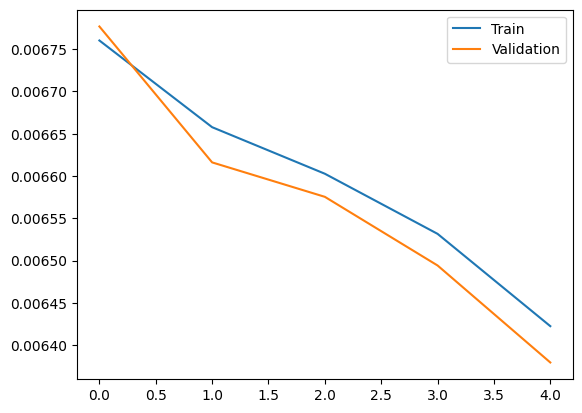

In [ ]:
plt.plot(
history.history['loss'],
label='Train'
)

plt.plot(
history.history['val_loss'],
label='Validation'
)

plt.legend()
plt.show()

In [ ]:
pred=model.predict(
X_test
)

pred_real=y_scaler.inverse_transform(
pred
)

actual_real=y_scaler.inverse_transform(
y_test.reshape(-1,1)
)

2476/2476 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step


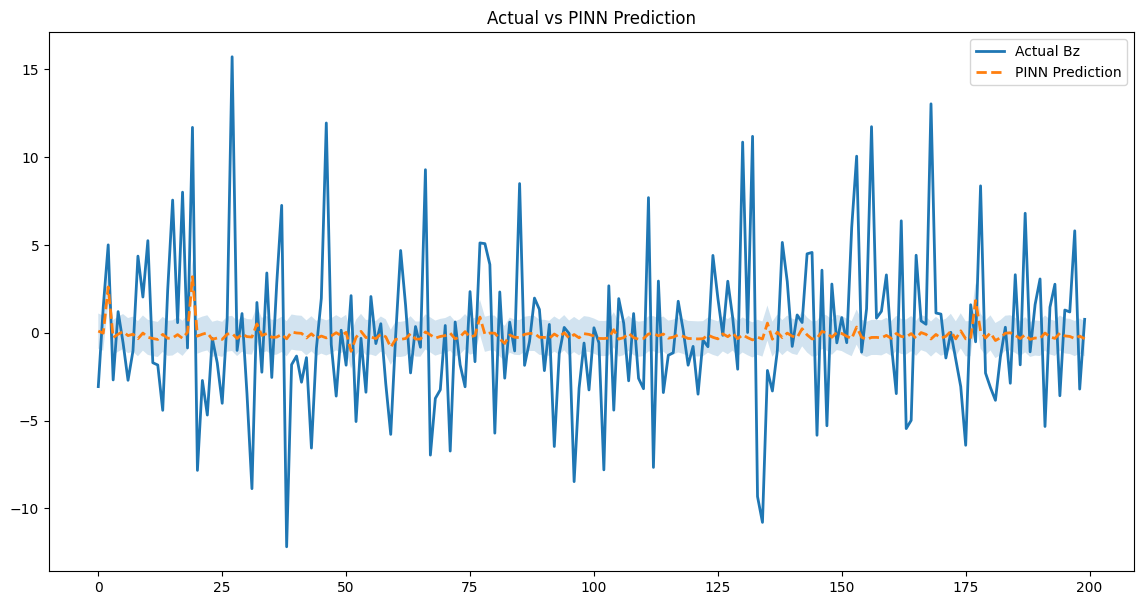

In [ ]:
plt.figure(
figsize=(14,7)
)

plt.plot(
actual_real[:200],
label='Actual Bz',
linewidth=2
)

plt.plot(
pred_real[:200],
'--',
label='PINN Prediction',
linewidth=2
)

plt.fill_between(
range(200),
pred_real[:200,0]-1,
pred_real[:200,0]+1,
alpha=0.2
)

plt.legend()

plt.title(
'Actual vs PINN Prediction'
)

plt.show()

In [ ]:
rmse=np.sqrt(
mean_squared_error(
actual_real,
pred_real
)
)

mae=mean_absolute_error(
actual_real,
pred_real
)

print(
"RMSE:",
rmse
)

print(
"MAE:",
mae
)

RMSE: 3.9169208632684045
MAE: 2.9093240580915793


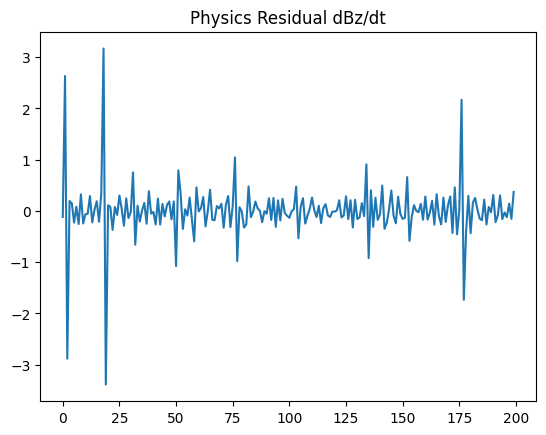

In [ ]:
residual=np.diff(
pred_real[:,0]
)

plt.plot(
residual[:200]
)

plt.title(
"Physics Residual dBz/dt"
)

plt.show()

In [ ]:
def storm_level(bz):

 if bz<-10:
   return "HIGH"

 elif bz<-5:
   return "MEDIUM"

 else:
   return "LOW"

In [ ]:
def cme_probability(
bz
):
 return min(
abs(bz)*5,
100
)

In [ ]:
threshold=np.mean(
abs(actual_real)
)+2*np.std(
abs(actual_real)
)

anomalies=np.where(
abs(actual_real)>threshold
)

print(
"Detected anomalies:",
len(anomalies[0])
)

Detected anomalies: 3654


In [ ]:
last_seq=X_scaled[-20:]

future=[]

current=last_seq.copy()

for i in range(24):

 p=model.predict(
 current.reshape(
1,20,5
),
verbose=0
 )[0][0]

 future.append(p)

 current=np.roll(
 current,
 -1,
 axis=0
 )

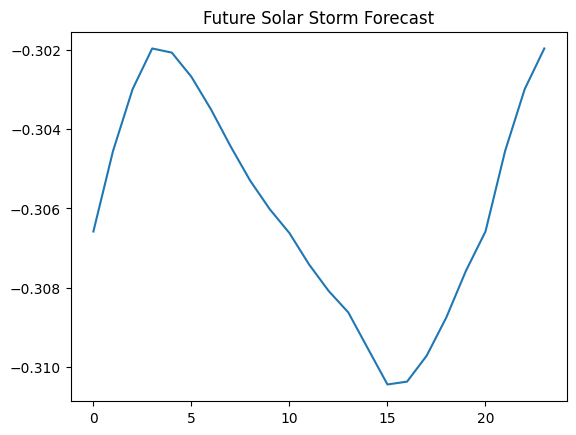

In [ ]:
future_real=y_scaler.inverse_transform(
np.array(
future
).reshape(-1,1)
)

plt.plot(
future_real
)

plt.title(
"Future Solar Storm Forecast"
)

plt.show()

In [ ]:
bx=widgets.FloatText(description='Bx')
by=widgets.FloatText(description='By')
speed=widgets.FloatText(description='Speed')
density=widgets.FloatText(description='Density')
temp=widgets.FloatText(description='Temp')

button=widgets.Button(
description='Predict'
)

out=widgets.Output()

In [ ]:
def predict_system(b):

 with out:

  out.clear_output()

  inp=np.array([[
  bx.value,
  by.value,
  speed.value,
  density.value,
  temp.value
  ]])

  inp_scaled=X_scaler.transform(inp)

  seq=np.array(
  [inp_scaled]*20
  ).reshape(1,20,5)

  bz=model.predict(
  seq,
  verbose=0
  )[0][0]

  bz=y_scaler.inverse_transform(
  [[bz]]
  )[0][0]

  print(
  "Predicted Bz:",
  bz
  )

  print(
  "Storm Risk:",
  storm_level(bz)
  )

  print(
  "CME Probability:",
  cme_probability(bz),
  "%"
  )

button.on_click(
predict_system
)

In [ ]:
display(
bx,by,speed,
density,temp,
button,out
)

FloatText(value=0.0, description='Bx')

FloatText(value=0.0, description='By')

FloatText(value=0.0, description='Speed')

FloatText(value=0.0, description='Density')

FloatText(value=0.0, description='Temp')

Button(description='Predict', style=ButtonStyle())

Output()